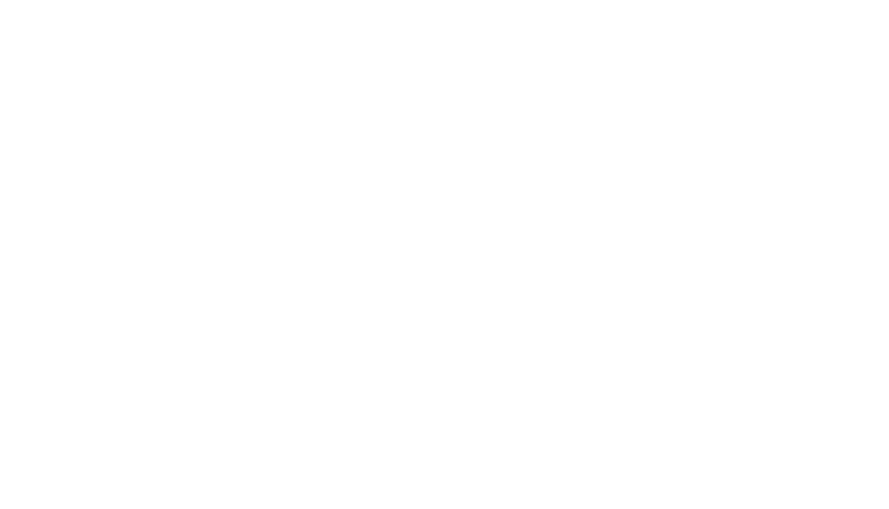

In [ ]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple, Union
import numpy as np
import matplotlib.pyplot as plt

# Import this to handle transparent display correctly in Notebooks
from IPython.display import display

Color = Union[str, Tuple[float, float, float]]

# ... (Keep your dataclasses and normal_pdf function exactly the same) ...
# ... (Keep plot_normal_curve_on_ax exactly the same) ...

@dataclass(frozen=True)
class ShadeRegionAbs:
    lower: float
    upper: float
    shade_strength_percent: float = 35.0
    color: Optional[Color] = None
    label: Optional[str] = None

@dataclass(frozen=True)
class ShadeRegionRelToMean:
    lower_offset: float
    upper_offset: float
    shade_strength_percent: float = 35.0
    color: Optional[Color] = None
    label: Optional[str] = None

def normal_pdf(x: np.ndarray, mu: float, sigma: float) -> np.ndarray:
    if sigma <= 0:
        raise ValueError("sigma must be > 0")
    z = (x - mu) / sigma
    return (1.0 / (sigma * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * z * z)

def plot_normal_curve_on_ax(
    *,
    ax: plt.Axes,
    mu: float,
    sigma: float,
    x_min: float,
    x_max: float,
    num_points: int = 1500,
    curve_color: Color = "white",
    curve_linewidth: float = 2.5,
    label: Optional[str] = None,
    shade_abs: Optional[List[ShadeRegionAbs]] = None,
    shade_rel_to_mean: Optional[List[ShadeRegionRelToMean]] = None,
) -> None:

    x = np.linspace(x_min, x_max, num_points)
    y = normal_pdf(x, mu, sigma)

    if label is None:
        label = f"μ={mu:g}, σ={sigma:g}"

    ax.plot(x, y, linewidth=curve_linewidth, color=curve_color, label=label)

    regions: List[ShadeRegionAbs] = []
    if shade_abs:
        regions.extend(shade_abs)

    if shade_rel_to_mean:
        for r in shade_rel_to_mean:
            regions.append(
                ShadeRegionAbs(
                    lower=mu - r.lower_offset,
                    upper=mu + r.upper_offset,
                    shade_strength_percent=r.shade_strength_percent,
                    color=r.color,
                    label=r.label,
                )
            )

    for region in regions:
        lower = min(region.lower, region.upper)
        upper = max(region.lower, region.upper)

        lower_clip = x_min if np.isneginf(lower) else max(lower, x_min)
        upper_clip = x_max if np.isposinf(upper) else min(upper, x_max)

        if upper_clip <= lower_clip:
            continue

        alpha = max(0.0, min(1.0, region.shade_strength_percent / 100.0))
        region_color = region.color if region.color else curve_color

        mask = (x >= lower_clip) & (x <= upper_clip)
        ax.fill_between(x[mask], 0.0, y[mask], alpha=alpha, color=region_color)

# ---------------------------
# Multi-distribution wrapper
# ---------------------------
def compare_normal_distributions(
    *,
    distributions: List[Dict[str, Any]],
    title: Optional[str] = None,
    xlabel: str = "x",
    ylabel: str = "Density",
    show_grid: bool = False,
    show_legend: bool = True,
    legend_loc: str = "best",
    show_ticks: bool = True,
    minimalist: bool = False,
    presentation_mode: bool = False,
    num_points: int = 1500,
    k_sigmas: float = 4.0,
    tick_step: Optional[float] = 2.0,
    figsize: Tuple[float, float] = (9, 5.2),
    save_path: Optional[str] = None,
    dpi: int = 300,
    transparent_background: bool = True,
) -> Tuple[plt.Figure, plt.Axes]:

    if not (1 <= len(distributions) <= 5):
        raise ValueError("Provide between 1 and 5 distributions.")

    # ... (Setup logic remains the same) ...
    if minimalist:
        show_grid = False
        show_ticks = False
        show_legend = False
        title = ""
        xlabel = ""
        ylabel = ""

    if presentation_mode:
        plt.rcParams.update(
            {
                "font.size": 14,
                "axes.titlesize": 16,
                "axes.labelsize": 14,
                "legend.fontsize": 12,
            }
        )

    mus = [float(d["mu"]) for d in distributions]
    sigmas = [float(d["sigma"]) for d in distributions]

    max_sigma = max(sigmas)
    min_mu = min(mus)
    max_mu = max(mus)

    x_min = min_mu - k_sigmas * max_sigma
    x_max = max_mu + k_sigmas * max_sigma

    mu_center = float(np.mean(mus))
    if tick_step is None:
        tick_step = 2.0

    x_ticks = np.arange(
        mu_center - 3 * max_sigma,
        mu_center + 3 * max_sigma + 1e-9,
        tick_step,
    )

    # ---- UPDATED FIGURE CREATION ----
    # 1. Initialize with figsize
    fig, ax = plt.subplots(figsize=figsize)
    
    # 2. Force alpha to 0.0 explicitly (more robust than facecolor="none")
    if transparent_background:
        fig.patch.set_alpha(0.0)
        ax.patch.set_alpha(0.0)
    
    # ... (Looping and Plotting remains same) ...
    for d in distributions:
        lw = float(d.get("linewidth", 2.5))
        if presentation_mode:
            lw = max(lw, 3.5)

        plot_normal_curve_on_ax(
            ax=ax,
            mu=float(d["mu"]),
            sigma=float(d["sigma"]),
            x_min=x_min,
            x_max=x_max,
            num_points=num_points,
            curve_color=d.get("color", "white"),
            curve_linewidth=lw,
            label=d.get("label"),
            shade_abs=d.get("shade_abs"),
            shade_rel_to_mean=d.get("shade_rel_to_mean"),
        )

    if title:
        ax.set_title(title)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if show_ticks:
        ax.set_xticks(x_ticks)
    else:
        ax.set_xticks([])
        ax.set_yticks([])

    if show_grid:
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

    ax.set_ylim(bottom=0.0)
    ax.margins(x=0.0, y=0.0)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if show_legend:
        ax.legend(loc=legend_loc)

    fig.tight_layout()

    if save_path:
        fig.savefig(
            save_path,
            dpi=dpi,
            transparent=transparent_background,
            bbox_inches="tight",
            pad_inches=0.02,
        )

    return fig, ax


# ---------------------------
# Example usage
# ---------------------------
if __name__ == "__main__":

    # NOTE: I changed color to Red to ensure you can see it on a white notebook background.
    # Change back to "#FFFFFF" if you have a dark theme.
    distributions = [
        {"mu": 181, "sigma": 6, "color": "#ffffff", "label": "Danish males (μ=181, σ=6)",
            "shade_abs": [ShadeRegionAbs(lower=-np.inf, upper=np.inf, shade_strength_percent=40, color='white')]},
    ]

    fig, ax = compare_normal_distributions(
        distributions=distributions,
        #xlabel="Height (cm)",
        #ylabel="Density",
        tick_step=3.0,
        show_ticks=True,
        show_legend=True,
        save_path=r"C:\Users\RIB\Downloads\heights_presentation.png", 
        transparent_background=True,
    )

    # Use display(fig) instead of plt.show()
    display(fig)
    plt.close(fig) # Prevents double plotting

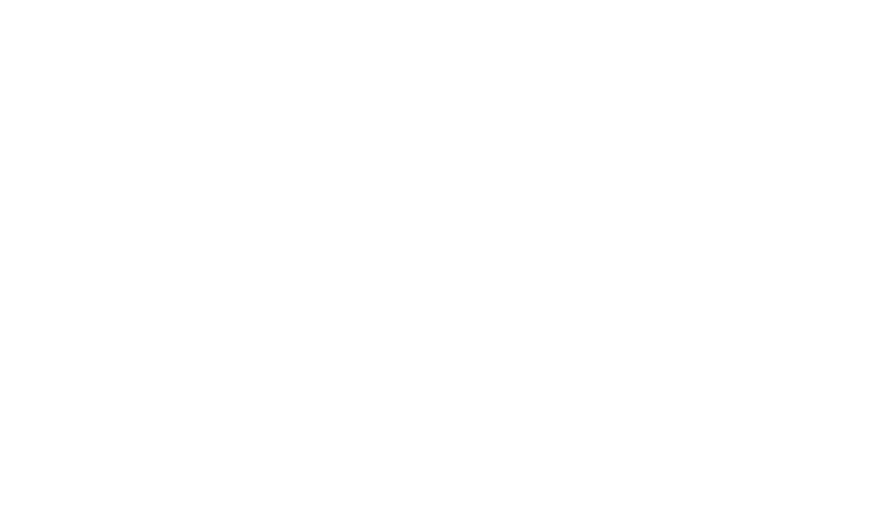

In [63]:
"""
General continuous PDF plotter (Matplotlib only) — user-defined functions

You provide:
- a PDF function f(x) (callable)
- domain endpoints [x_min, x_max]
Optionally:
- custom ticks (or auto ticks)
- shaded regions:
    * absolute [lower, upper]
    * relative to a reference point (e.g., "mean") via offsets
    * probability-driven shading (central/tails) IF you provide a CDF function

Also:
- curve sits on x-axis (y starts at 0, no bottom padding)
- only x and y axes (no frame)
- transparent background export
- show_ticks True/False, minimalist, presentation_mode

Requires:
    pip install numpy matplotlib
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, List, Optional, Tuple, Union, Any

import numpy as np
import matplotlib.pyplot as plt

# Sæt tekstfarve til hvid og baggrund til gennemsigtig (til mørk baggrund)
plt.rcParams.update({
    'text.color': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.edgecolor': 'white',
    'legend.frameon': False,
    'figure.facecolor': (0, 0, 0, 0),
    'axes.facecolor': (0, 0, 0, 0),
    'savefig.facecolor': (0, 0, 0, 0)
})


Color = Union[str, Tuple[float, float, float]]


# ---------------------------
# Shading structures
# ---------------------------
@dataclass(frozen=True)
class ShadeRegionAbs:
    lower: float
    upper: float
    shade_strength_percent: float = 35.0  # 0..100
    color: Optional[Color] = None
    label: Optional[str] = None


@dataclass(frozen=True)
class ShadeRegionRelToRef:
    """
    Region defined relative to a reference value r (often mean):
        lower = r - lower_offset
        upper = r + upper_offset
    """
    lower_offset: float
    upper_offset: float
    shade_strength_percent: float = 35.0  # 0..100
    color: Optional[Color] = None
    label: Optional[str] = None


# ---------------------------
# Utilities: numeric integration + inverse CDF (only needed if you want probability-based shading)
# ---------------------------
def _trapz_cdf_from_pdf(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Build an approximate CDF on grid x from PDF samples y via cumulative trapezoid integration."""
    # cumulative trapezoid (no scipy needed)
    dx = np.diff(x)
    area_steps = 0.5 * (y[:-1] + y[1:]) * dx
    cdf = np.concatenate([[0.0], np.cumsum(area_steps)])
    total = cdf[-1]
    if total <= 0:
        raise ValueError("PDF integrates to <= 0 over the provided domain.")
    return cdf / total


def _inv_cdf_from_grid(x: np.ndarray, cdf: np.ndarray, p: float) -> float:
    """Invert a monotone CDF given on a grid using linear interpolation."""
    if not (0.0 < p < 1.0):
        raise ValueError("p must be in (0,1)")
    # Ensure increasing; if numerical noise, enforce monotone non-decreasing
    cdf_mono = np.maximum.accumulate(cdf)
    return float(np.interp(p, cdf_mono, x))


def central_symmetric_region_via_cdf(
    *, ref: float, x_grid: np.ndarray, cdf_grid: np.ndarray, p: float,
    shade_strength_percent: float = 35.0, color: Optional[Color] = None, label: Optional[str] = None
) -> ShadeRegionAbs:
    """
    Central symmetric probability region around 'ref' using a CDF:
    Find a such that P(ref-a <= X <= ref+a) = p.
    This is done numerically by finding a where CDF(ref+a) - CDF(ref-a) = p.
    """
    if not (0.0 < p < 1.0):
        raise ValueError("p must be in (0,1)")

    # Helper to get CDF(x) by interpolation
    cdf_mono = np.maximum.accumulate(cdf_grid)

    def C(x: float) -> float:
        return float(np.interp(x, x_grid, cdf_mono))

    # Search for 'a' on a grid from 0 to max possible
    a_max = min(ref - x_grid[0], x_grid[-1] - ref)
    if a_max <= 0:
        raise ValueError("Reference point must be inside the domain for symmetric shading.")

    # Binary search on a in [0, a_max]
    lo, hi = 0.0, a_max
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        prob = C(ref + mid) - C(ref - mid)
        if prob < p:
            lo = mid
        else:
            hi = mid

    a = 0.5 * (lo + hi)
    return ShadeRegionAbs(
        lower=ref - a,
        upper=ref + a,
        shade_strength_percent=shade_strength_percent,
        color=color,
        label=label or f"Central {p:.3f}",
    )


def upper_tail_region_via_cdf(
    *, x_grid: np.ndarray, cdf_grid: np.ndarray, p: float,
    shade_strength_percent: float = 35.0, color: Optional[Color] = None, label: Optional[str] = None
) -> ShadeRegionAbs:
    """
    Shades [q, +inf) where P(X >= q) = p, i.e. q = inverse_cdf(1-p).
    """
    q = _inv_cdf_from_grid(x_grid, cdf_grid, 1.0 - p)
    return ShadeRegionAbs(
        lower=q,
        upper=np.inf,
        shade_strength_percent=shade_strength_percent,
        color=color,
        label=label or f"Upper tail {p:.3f}",
    )


def lower_tail_region_via_cdf(
    *, x_grid: np.ndarray, cdf_grid: np.ndarray, p: float,
    shade_strength_percent: float = 35.0, color: Optional[Color] = None, label: Optional[str] = None
) -> ShadeRegionAbs:
    """
    Shades (-inf, q] where P(X <= q) = p, i.e. q = inverse_cdf(p).
    """
    q = _inv_cdf_from_grid(x_grid, cdf_grid, p)
    return ShadeRegionAbs(
        lower=-np.inf,
        upper=q,
        shade_strength_percent=shade_strength_percent,
        color=color,
        label=label or f"Lower tail {p:.3f}",
    )


# ---------------------------
# Main plotter
# ---------------------------
def plot_continuous_pdf(
    *,
    pdf: Callable[[np.ndarray], np.ndarray],
    x_min: float,
    x_max: float,
    # resolution
    num_points: int = 2000,
    # style
    curve_color: Color = "black",
    curve_linewidth: float = 2.5,
    title: Optional[str] = None,
    xlabel: str = "x",
    ylabel: str = "Density",
    # ticks
    show_ticks: bool = True,
    x_ticks: Optional[np.ndarray] = None,
    # shading
    shade_abs: Optional[List[ShadeRegionAbs]] = None,
    shade_rel_to_ref: Optional[List[ShadeRegionRelToRef]] = None,
    ref_value: Optional[float] = None,  # e.g. mean; used only if shade_rel_to_ref is provided
    # probability-driven shading (optional): provide either a cdf(x) or set build_cdf_from_pdf=True
    cdf: Optional[Callable[[np.ndarray], np.ndarray]] = None,
    build_cdf_from_pdf: bool = False,
    # show/hide
    show_grid: bool = False,
    show_legend: bool = False,
    legend_loc: str = "best",
    # presets
    minimalist: bool = False,
    presentation_mode: bool = False,
    # export
    save_path: Optional[str] = None,
    dpi: int = 300,
    transparent_background: bool = True,
) -> Tuple[plt.Figure, plt.Axes, np.ndarray, np.ndarray, Optional[np.ndarray]]:
    """
    Returns (fig, ax, x_grid, pdf_grid, cdf_grid_or_None).
    """
    if x_max <= x_min:
        raise ValueError("x_max must be > x_min")
    if num_points < 2:
        raise ValueError("num_points must be >= 2")

    # Apply presets
    if minimalist:
        show_grid = False
        show_ticks = False
        show_legend = False
        title = "" if title is None else title
        xlabel = "" if xlabel == "x" else xlabel
        ylabel = "" if ylabel == "Density" else ylabel

    if presentation_mode:
        plt.rcParams.update(
            {
                "font.size": 14,
                "axes.titlesize": 16,
                "axes.labelsize": 14,
                "legend.fontsize": 12,
                "xtick.labelsize": 12,
                "ytick.labelsize": 12,
            }
        )
        curve_linewidth = max(curve_linewidth, 3.5)

    x = np.linspace(x_min, x_max, num_points)
    y = pdf(x)

    y = np.asarray(y, dtype=float)
    if y.shape != x.shape:
        raise ValueError("pdf(x) must return an array of the same shape as x")

    # Guardrails: PDFs should be nonnegative; we clamp tiny negatives from numerical noise
    y = np.maximum(y, 0.0)

    # Optional CDF grid (for probability shading)
    cdf_grid: Optional[np.ndarray] = None
    if cdf is not None:
        cdf_vals = np.asarray(cdf(x), dtype=float)
        if cdf_vals.shape != x.shape:
            raise ValueError("cdf(x) must return an array of the same shape as x")
        cdf_grid = np.maximum.accumulate(cdf_vals)
        # normalize if user provided non-normalized CDF on [x_min,x_max]
        cdf_grid = (cdf_grid - cdf_grid[0]) / max(1e-12, (cdf_grid[-1] - cdf_grid[0]))
    elif build_cdf_from_pdf:
        cdf_grid = _trapz_cdf_from_pdf(x, y)

    fig, ax = plt.subplots(figsize=(9, 5.2))

    # Plot curve
    ax.plot(x, y, linewidth=curve_linewidth, color=curve_color, label=title if title else None)

    # Build combined shading list
    regions: List[ShadeRegionAbs] = []
    if shade_abs:
        regions.extend(shade_abs)

    if shade_rel_to_ref:
        if ref_value is None:
            raise ValueError("ref_value must be provided when using shade_rel_to_ref.")
        for r in shade_rel_to_ref:
            regions.append(
                ShadeRegionAbs(
                    lower=ref_value - r.lower_offset,
                    upper=ref_value + r.upper_offset,
                    shade_strength_percent=r.shade_strength_percent,
                    color=r.color,
                    label=r.label,
                )
            )

    # Shade absolute regions
    for region in regions:
        lower = min(region.lower, region.upper)
        upper = max(region.lower, region.upper)

        lower_clip = x_min if np.isneginf(lower) else max(lower, x_min)
        upper_clip = x_max if np.isposinf(upper) else min(upper, x_max)
        if upper_clip <= lower_clip:
            continue

        alpha = max(0.0, min(1.0, float(region.shade_strength_percent) / 100.0))
        region_color = region.color if region.color is not None else curve_color

        mask = (x >= lower_clip) & (x <= upper_clip)
        ax.fill_between(x[mask], 0.0, y[mask], alpha=alpha, color=region_color, linewidth=0)

    # Labels
    if title:
        ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Ticks
    if show_ticks:
        if x_ticks is not None:
            ax.set_xticks(x_ticks)
    else:
        ax.set_xticks([])
        ax.set_yticks([])

    # Grid
    if show_grid:
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

    # Curve sits on x-axis, no padding
    ax.set_ylim(bottom=0.0)
    ax.margins(x=0.0, y=0.0)

    # Only x and y axes (no frame)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if show_legend:
        ax.legend(loc=legend_loc)

    fig.tight_layout()

    if save_path:
        fig.savefig(
            save_path,
            dpi=dpi,
            transparent=transparent_background,
            bbox_inches="tight",
            pad_inches=0.02,
        )

    return fig, ax, x, y, cdf_grid


# ---------------------------
# Example usage
# ---------------------------
if __name__ == "__main__":

    def my_pdf(x: np.ndarray) -> np.ndarray:
        # Example PDF supported on [2,4]
        y = 1/60 * x**3
        return y

    x_min, x_max = 2, 4

    # Step 1 — Build CDF numerically without plotting
    x_grid = np.linspace(x_min, x_max, 2000)
    pdf_grid = my_pdf(x_grid)
    pdf_grid = np.maximum(pdf_grid, 0.0)

    cdf_grid = _trapz_cdf_from_pdf(x_grid, pdf_grid)

    # Median
    lower50 = lower_tail_region_via_cdf(
    x_grid=x_grid,
    cdf_grid=cdf_grid,
    p=0.5,
    shade_strength_percent=40
    )

    # Percentiles
    p1 = _inv_cdf_from_grid(x_grid, cdf_grid, 0.10)
    p2 = _inv_cdf_from_grid(x_grid, cdf_grid, 0.90)

    # Shade Q1 to Q3
    p_region = ShadeRegionAbs(
        lower=p1,
        upper=p2,
        shade_strength_percent=40
    )

    
    fig, ax, x_grid, pdf_grid, cdf_grid = plot_continuous_pdf(
        pdf=my_pdf,
        x_min=x_min,
        x_max=x_max,
        curve_color="#ffffff",
        #title="Example PDF on [2,4]",
        #shade_abs=[p_region],
        shade_abs=[
        ShadeRegionAbs(lower=2, upper=2.7, shade_strength_percent=40)
        ],
        build_cdf_from_pdf=True,
        show_ticks=True,
        transparent_background=True,
    )

    # ✅ Manually extend the axis beyond the PDF support
    ax.set_xlim(1.5, 4.5)   # you choose these freely

    fig.savefig(
    r"C:\Users\RIB\Downloads\udf_cont.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.02,
    )

    
    # If you also want to control y-range:
    # ax.set_ylim(0, 1.1)

    plt.show()

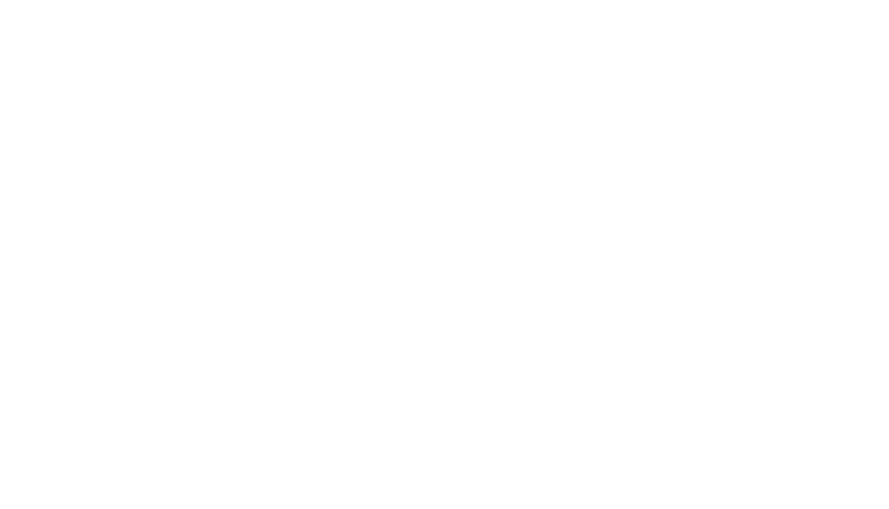

In [46]:
"""
General continuous PDF plotter (Matplotlib only) — user-defined functions

WITH:
- Gamma distribution logic added (Time to Failure)
- White text / Transparent background settings enabled
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, List, Optional, Tuple, Union, Any

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma  # <--- Added for the math

# ---------------------------
# GLOBAL STYLE SETTINGS (White text / Transparent BG)
# ---------------------------
plt.rcParams.update({
    'text.color': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.edgecolor': 'white',
    'legend.frameon': False,
    'figure.facecolor': (0, 0, 0, 0),  # Transparent figure
    'axes.facecolor': (0, 0, 0, 0),    # Transparent axis
    'savefig.facecolor': (0, 0, 0, 0)  # Transparent export
})


Color = Union[str, Tuple[float, float, float]]


# ---------------------------
# Shading structures
# ---------------------------
@dataclass(frozen=True)
class ShadeRegionAbs:
    lower: float
    upper: float
    shade_strength_percent: float = 35.0  # 0..100
    color: Optional[Color] = None
    label: Optional[str] = None


@dataclass(frozen=True)
class ShadeRegionRelToRef:
    lower_offset: float
    upper_offset: float
    shade_strength_percent: float = 35.0
    color: Optional[Color] = None
    label: Optional[str] = None


# ---------------------------
# Utilities
# ---------------------------
def _trapz_cdf_from_pdf(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    dx = np.diff(x)
    area_steps = 0.5 * (y[:-1] + y[1:]) * dx
    cdf = np.concatenate([[0.0], np.cumsum(area_steps)])
    total = cdf[-1]
    if total <= 0:
        raise ValueError("PDF integrates to <= 0 over the provided domain.")
    return cdf / total


def _inv_cdf_from_grid(x: np.ndarray, cdf: np.ndarray, p: float) -> float:
    if not (0.0 < p < 1.0):
        raise ValueError("p must be in (0,1)")
    cdf_mono = np.maximum.accumulate(cdf)
    return float(np.interp(p, cdf_mono, x))


def lower_tail_region_via_cdf(
    *, x_grid: np.ndarray, cdf_grid: np.ndarray, p: float,
    shade_strength_percent: float = 35.0, color: Optional[Color] = None, label: Optional[str] = None
) -> ShadeRegionAbs:
    q = _inv_cdf_from_grid(x_grid, cdf_grid, p)
    return ShadeRegionAbs(
        lower=-np.inf,
        upper=q,
        shade_strength_percent=shade_strength_percent,
        color=color,
        label=label or f"Lower tail {p:.3f}",
    )


# ---------------------------
# Main plotter
# ---------------------------
def plot_continuous_pdf(
    *,
    pdf: Callable[[np.ndarray], np.ndarray],
    x_min: float,
    x_max: float,
    num_points: int = 2000,
    curve_color: Color = "white",  # Changed default to white
    curve_linewidth: float = 2.5,
    title: Optional[str] = None,
    xlabel: str = "x",
    ylabel: str = "Density",
    show_ticks: bool = True,
    x_ticks: Optional[np.ndarray] = None,
    shade_abs: Optional[List[ShadeRegionAbs]] = None,
    shade_rel_to_ref: Optional[List[ShadeRegionRelToRef]] = None,
    ref_value: Optional[float] = None,
    cdf: Optional[Callable[[np.ndarray], np.ndarray]] = None,
    build_cdf_from_pdf: bool = False,
    show_grid: bool = False,
    show_legend: bool = False,
    legend_loc: str = "best",
    minimalist: bool = False,
    presentation_mode: bool = False,
    save_path: Optional[str] = None,
    dpi: int = 300,
    transparent_background: bool = True,
) -> Tuple[plt.Figure, plt.Axes, np.ndarray, np.ndarray, Optional[np.ndarray]]:

    if x_max <= x_min:
        raise ValueError("x_max must be > x_min")
    
    # Pre-calculation for PDF/CDF
    x = np.linspace(x_min, x_max, num_points)
    y = pdf(x)
    y = np.asarray(y, dtype=float)
    y = np.maximum(y, 0.0)

    cdf_grid: Optional[np.ndarray] = None
    if cdf is not None:
        cdf_vals = np.asarray(cdf(x), dtype=float)
        cdf_grid = np.maximum.accumulate(cdf_vals)
        cdf_grid = (cdf_grid - cdf_grid[0]) / max(1e-12, (cdf_grid[-1] - cdf_grid[0]))
    elif build_cdf_from_pdf:
        cdf_grid = _trapz_cdf_from_pdf(x, y)

    # Plot Setup
    fig, ax = plt.subplots(figsize=(9, 5.2))
    
    # Ensure transparent background logic is enforced explicitly
    if transparent_background:
        fig.patch.set_alpha(0.0)
        ax.patch.set_alpha(0.0)

    # Plot Curve
    ax.plot(x, y, linewidth=curve_linewidth, color=curve_color, label=title if title else None)

    # Shading Logic
    regions: List[ShadeRegionAbs] = []
    if shade_abs:
        regions.extend(shade_abs)
    if shade_rel_to_ref:
        if ref_value is None:
            raise ValueError("ref_value must be provided when using shade_rel_to_ref.")
        for r in shade_rel_to_ref:
            regions.append(
                ShadeRegionAbs(
                    lower=ref_value - r.lower_offset,
                    upper=ref_value + r.upper_offset,
                    shade_strength_percent=r.shade_strength_percent,
                    color=r.color,
                    label=r.label,
                )
            )

    for region in regions:
        lower = min(region.lower, region.upper)
        upper = max(region.lower, region.upper)
        lower_clip = x_min if np.isneginf(lower) else max(lower, x_min)
        upper_clip = x_max if np.isposinf(upper) else min(upper, x_max)

        if upper_clip <= lower_clip:
            continue

        alpha = max(0.0, min(1.0, float(region.shade_strength_percent) / 100.0))
        region_color = region.color if region.color is not None else curve_color

        mask = (x >= lower_clip) & (x <= upper_clip)
        ax.fill_between(x[mask], 0.0, y[mask], alpha=alpha, color=region_color, linewidth=0)

    # Styling
    if title:
        ax.set_title(title, pad=20) # Added pad for better look
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if show_ticks:
        if x_ticks is not None:
            ax.set_xticks(x_ticks)
    else:
        ax.set_xticks([])
        ax.set_yticks([])

    if show_grid:
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

    ax.set_ylim(bottom=0.0)
    ax.margins(x=0.0, y=0.0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if show_legend:
        ax.legend(loc=legend_loc)

    fig.tight_layout()

    if save_path:
        fig.savefig(
            save_path,
            dpi=dpi,
            transparent=transparent_background,
            bbox_inches="tight",
            pad_inches=0.02,
        )

    return fig, ax, x, y, cdf_grid


# ---------------------------
# UPDATED FUNCTION FOR TIME TO FAILURE
# ---------------------------
if __name__ == "__main__":

    # 1. Define the Math (Gamma Distribution)
    def time_to_failure_pdf(x: np.ndarray) -> np.ndarray:
        # Parameters estimated from your image
        shape = 2.0
        scale = 0.66
        
        # Gamma PDF formula: (x^(k-1) * e^(-x/theta)) / (theta^k * Gamma(k))
        coef = 1.0 / ((scale ** shape) * gamma(shape))
        val = coef * (x ** (shape - 1)) * np.exp(-x / scale)
        
        return np.where(x < 0, 0, val)

    # 3. Run the Plotter
    x_min, x_max = 0, 5

    fig, ax, _, _, _ = plot_continuous_pdf(
        pdf=time_to_failure_pdf,
        x_min=x_min,
        x_max=x_max,
        
        # Visuals
        curve_color="white", # Outline color
        curve_linewidth=2.5,
        shade_abs=[
        ShadeRegionAbs(lower=0, upper=5, color="#ffffff", shade_strength_percent=40)
        ],
        
        # Text
        xlabel="Time to Failure (x)",
        ylabel=r"$f(x)$",
        #title="Distribution of time to failure (in thousands\nof hours) for a type of light bulb:",
        
        # Configuration
        show_ticks=True,
        transparent_background=True,
        save_path= r"C:\Users\RIB\Downloads\gamma.png"
    )

    plt.show()

Saved 'normal_prob_shaded.png'.


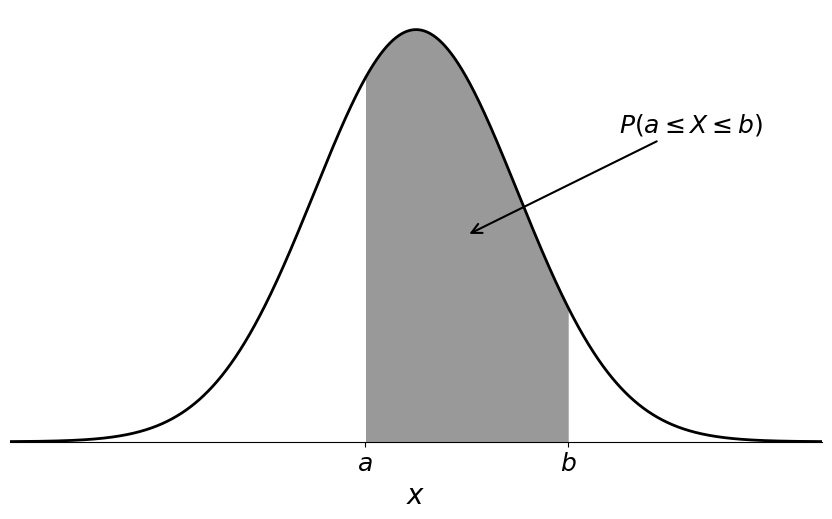

In [26]:
"""
General continuous PDF plotter (Matplotlib only) — user-defined functions

WITH:
- Gamma distribution logic added (Time to Failure)
- White text / Transparent background settings enabled
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, List, Optional, Tuple, Union, Any

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma  # <--- Added for the math

# ---------------------------
# GLOBAL STYLE SETTINGS (White text / Transparent BG)
# ---------------------------
plt.rcParams.update({
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.edgecolor': 'black',
    'legend.frameon': False,
    'figure.facecolor': (0, 0, 0, 0),  # Transparent figure
    'axes.facecolor': (0, 0, 0, 0),    # Transparent axis
    'savefig.facecolor': (0, 0, 0, 0)  # Transparent export
})


Color = Union[str, Tuple[float, float, float]]


# ---------------------------
# Shading structures
# ---------------------------
@dataclass(frozen=True)
class ShadeRegionAbs:
    lower: float
    upper: float
    shade_strength_percent: float = 35.0  # 0..100
    color: Optional[Color] = None
    label: Optional[str] = None


@dataclass(frozen=True)
class ShadeRegionRelToRef:
    lower_offset: float
    upper_offset: float
    shade_strength_percent: float = 35.0
    color: Optional[Color] = None
    label: Optional[str] = None


# ---------------------------
# Utilities
# ---------------------------
def _trapz_cdf_from_pdf(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    dx = np.diff(x)
    area_steps = 0.5 * (y[:-1] + y[1:]) * dx
    cdf = np.concatenate([[0.0], np.cumsum(area_steps)])
    total = cdf[-1]
    if total <= 0:
        raise ValueError("PDF integrates to <= 0 over the provided domain.")
    return cdf / total


def _inv_cdf_from_grid(x: np.ndarray, cdf: np.ndarray, p: float) -> float:
    if not (0.0 < p < 1.0):
        raise ValueError("p must be in (0,1)")
    cdf_mono = np.maximum.accumulate(cdf)
    return float(np.interp(p, cdf_mono, x))


def lower_tail_region_via_cdf(
    *, x_grid: np.ndarray, cdf_grid: np.ndarray, p: float,
    shade_strength_percent: float = 35.0, color: Optional[Color] = None, label: Optional[str] = None
) -> ShadeRegionAbs:
    q = _inv_cdf_from_grid(x_grid, cdf_grid, p)
    return ShadeRegionAbs(
        lower=-np.inf,
        upper=q,
        shade_strength_percent=shade_strength_percent,
        color=color,
        label=label or f"Lower tail {p:.3f}",
    )


# ---------------------------
# Main plotter
# ---------------------------
def plot_continuous_pdf(
    *,
    pdf: Callable[[np.ndarray], np.ndarray],
    x_min: float,
    x_max: float,
    num_points: int = 2000,
    curve_color: Color = "white",  # Changed default to white
    curve_linewidth: float = 2.5,
    title: Optional[str] = None,
    xlabel: str = "x",
    ylabel: str = "Density",
    show_ticks: bool = True,
    x_ticks: Optional[np.ndarray] = None,
    shade_abs: Optional[List[ShadeRegionAbs]] = None,
    shade_rel_to_ref: Optional[List[ShadeRegionRelToRef]] = None,
    ref_value: Optional[float] = None,
    cdf: Optional[Callable[[np.ndarray], np.ndarray]] = None,
    build_cdf_from_pdf: bool = False,
    show_grid: bool = False,
    show_legend: bool = False,
    legend_loc: str = "best",
    minimalist: bool = False,
    presentation_mode: bool = False,
    save_path: Optional[str] = None,
    dpi: int = 300,
    transparent_background: bool = True,
) -> Tuple[plt.Figure, plt.Axes, np.ndarray, np.ndarray, Optional[np.ndarray]]:

    if x_max <= x_min:
        raise ValueError("x_max must be > x_min")
    
    # Pre-calculation for PDF/CDF
    x = np.linspace(x_min, x_max, num_points)
    y = pdf(x)
    y = np.asarray(y, dtype=float)
    y = np.maximum(y, 0.0)

    cdf_grid: Optional[np.ndarray] = None
    if cdf is not None:
        cdf_vals = np.asarray(cdf(x), dtype=float)
        cdf_grid = np.maximum.accumulate(cdf_vals)
        cdf_grid = (cdf_grid - cdf_grid[0]) / max(1e-12, (cdf_grid[-1] - cdf_grid[0]))
    elif build_cdf_from_pdf:
        cdf_grid = _trapz_cdf_from_pdf(x, y)

    # Plot Setup
    fig, ax = plt.subplots(figsize=(9, 5.2))
    
    # Ensure transparent background logic is enforced explicitly
    if transparent_background:
        fig.patch.set_alpha(0.0)
        ax.patch.set_alpha(0.0)

    # Plot Curve
    ax.plot(x, y, linewidth=curve_linewidth, color=curve_color, label=title if title else None)

    # Shading Logic
    regions: List[ShadeRegionAbs] = []
    if shade_abs:
        regions.extend(shade_abs)
    if shade_rel_to_ref:
        if ref_value is None:
            raise ValueError("ref_value must be provided when using shade_rel_to_ref.")
        for r in shade_rel_to_ref:
            regions.append(
                ShadeRegionAbs(
                    lower=ref_value - r.lower_offset,
                    upper=ref_value + r.upper_offset,
                    shade_strength_percent=r.shade_strength_percent,
                    color=r.color,
                    label=r.label,
                )
            )

    for region in regions:
        lower = min(region.lower, region.upper)
        upper = max(region.lower, region.upper)
        lower_clip = x_min if np.isneginf(lower) else max(lower, x_min)
        upper_clip = x_max if np.isposinf(upper) else min(upper, x_max)

        if upper_clip <= lower_clip:
            continue

        alpha = max(0.0, min(1.0, float(region.shade_strength_percent) / 100.0))
        region_color = region.color if region.color is not None else curve_color

        mask = (x >= lower_clip) & (x <= upper_clip)
        ax.fill_between(x[mask], 0.0, y[mask], alpha=alpha, color=region_color, linewidth=0)

    # Styling
    if title:
        ax.set_title(title, pad=20) # Added pad for better look
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if show_ticks:
        if x_ticks is not None:
            ax.set_xticks(x_ticks)
    else:
        ax.set_xticks([])
        ax.set_yticks([])

    if show_grid:
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

    ax.set_ylim(bottom=0.0)
    ax.margins(x=0.0, y=0.0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if show_legend:
        ax.legend(loc=legend_loc)

    fig.tight_layout()

    if save_path:
        fig.savefig(
            save_path,
            dpi=dpi,
            transparent=transparent_background,
            bbox_inches="tight",
            pad_inches=0.02,
        )

    return fig, ax, x, y, cdf_grid


# ---------------------------
# REPLICATION OF NORMAL SHADED PLOT
# ---------------------------
if __name__ == "__main__":

    # 1. Define Standard Normal Function
    def normal_pdf(x: np.ndarray) -> np.ndarray:
        # Standard normal: mu=0, sigma=1
        return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

    # 2. Define the Region [a, b]
    # Visually, 'a' looks like -1.0 and 'b' looks like 1.5
    a_val = -0.5
    b_val = 1.5
    
    gray_shading = ShadeRegionAbs(
        lower=a_val,
        upper=b_val,
        shade_strength_percent=40, # Solid opacity
        color="black",            # Light gray color matching the image
    )

    # 3. Create the Plot
    x_min, x_max = -4, 4

    fig, ax, _, _, _ = plot_continuous_pdf(
        pdf=normal_pdf,
        x_min=x_min,
        x_max=x_max,
        shade_abs=[gray_shading],
        
        # Style settings
        curve_color="black",
        curve_linewidth=2.0,
        xlabel="$x$",          # LaTeX formatted x-label
        ylabel="",             # No y-label needed
        title=None,
        
        # We turn ticks ON here, but we will customize them manually below
        show_ticks=True, 
        transparent_background=True,
        save_path="normal_prob_shaded.png"
    )

    # --- MANUAL CUSTOMIZATIONS TO MATCH IMAGE EXACTLY ---

    # 1. Set specific ticks for 'a' and 'b' only
    ax.set_xticks([a_val, b_val])
    ax.set_xticklabels([r"$a$", r"$b$"], fontsize=18) # LaTeX labels
    
    # 2. Hide the Y-axis and Y-ticks completely (only show bottom line)
    ax.yaxis.set_visible(False)
    ax.spines['left'].set_visible(False)

    # 3. Add the Arrow and Text P(a < X < b)
    # xy = point to point at (middle of curve), xytext = where text sits
    ax.annotate(
        r"$P(a \leq X \leq b)$", 
        xy=(0.5, 0.20),           # The arrow tip location
        xytext=(2.0, 0.30),       # The text location
        fontsize=18, 
        color="black",
        arrowprops=dict(arrowstyle="->", color="black", lw=1.5)
    )

    # 4. Enlarge x-axis label size to match image
    ax.xaxis.label.set_size(20)

    # Save again to capture the manual changes (ticks/arrows)
    fig.savefig(r"C:\Users\RIB\Downloads\normal_prob_shaded.png", dpi=300, transparent=False, bbox_inches="tight")
    
    print("Saved 'normal_prob_shaded.png'.")
    plt.show()

Saved 'uniform_box_transparent.png'.


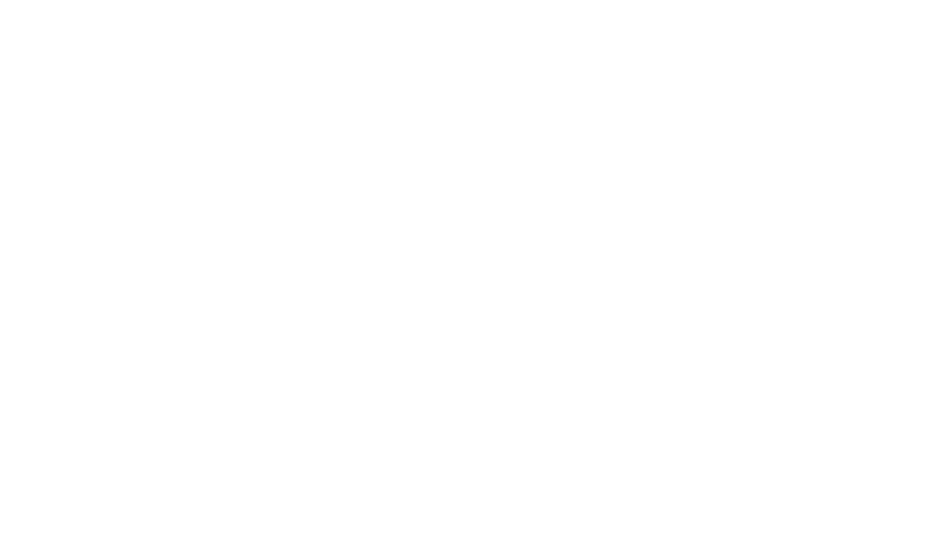

In [ ]:
# ---------------------------
# UNIFORM DISTRIBUTION (BOX) PLOT — Black text, white background, blue box
# Self-contained: only numpy and matplotlib (no other cells required).
# ---------------------------
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.edgecolor': 'black',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white'
})

c, d = 2.0, 6.0
height = 0.5
box_blue = "#2563eb"
x_min, x_max = 0, 8

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Draw box: fill between c and d at height
ax.fill_between([c, d], 0, height, color=box_blue, alpha=0.4)
ax.hlines(height, c, d, colors=box_blue, linewidth=2.0)
ax.vlines([c, d], 0, height, colors=box_blue, linewidth=2.0)
ax.hlines(0, x_min, x_max, colors=box_blue, linewidth=1.0)

ax.set_xticks([c, d])
ax.set_xticklabels([r"$a$", r"$b$"], fontsize=20)
ax.set_yticks([0])
ax.set_yticklabels(["0"], fontsize=16)
ax.set_xlabel(r"$x$", fontsize=20)
ax.set_ylabel(r"$f(x)$", fontsize=16)
ax.yaxis.label.set_rotation(0)
ax.yaxis.set_label_coords(-0.1, 0.5)
ax.set_ylim(0, height + 0.3)
ax.set_xlim(x_min, x_max)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

fig.savefig("uniform_box.png", dpi=300, transparent=False, facecolor='white', bbox_inches="tight")
print("Saved 'uniform_box.png'.")
plt.show()

Saved 'dice_simulation_100.png'. Drag this into OneNote.


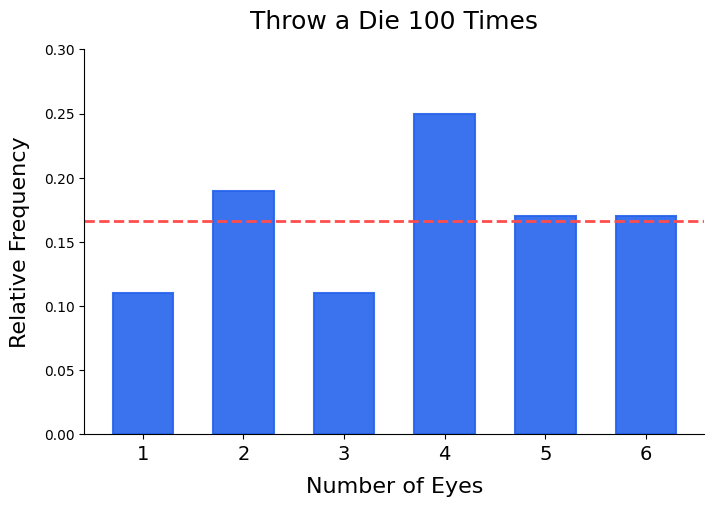

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# GLOBAL STYLE SETTINGS (Black text / White BG)
# ---------------------------
plt.rcParams.update({
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.edgecolor': 'black',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white'
})

if __name__ == "__main__":
    
    # 1. Simulate the Data
    np.random.seed(42)  # Fixed seed so you get the same "random" plot every time
    n_throws = 100
    
    # Generate 100 integers between 1 and 6
    outcomes = np.random.randint(1, 7, n_throws)
    
    # Count frequency of each face (1-6)
    faces = np.arange(1, 7)
    counts = np.array([np.sum(outcomes == f) for f in faces])
    
    # Calculate relative frequency (probability)
    probs = counts / n_throws

    # 2. Create the Plot
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Plot Bars
    bars = ax.bar(faces, probs, color="#2563eb", alpha=0.9, edgecolor="#2563eb", linewidth=1.5, width=0.6)

    # 3. Add Theoretical Line (1/6) for comparison
    # Used a dashed red line to illustrate the "True" uniform distribution
    theoretical_p = 1/6
    ax.axhline(y=theoretical_p, color="#ff4d4d", linestyle="--", linewidth=2, label="Theoretical (1/6)")

    # 4. Styling
    ax.set_xticks(faces)
    ax.set_xticklabels(faces, fontsize=14)
    
    ax.set_xlabel("Number of Eyes", fontsize=16, labelpad=10)
    ax.set_ylabel("Relative Frequency", fontsize=16, labelpad=10)
    
    # Remove top and right spines (Frame)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Set Y-axis limits with some headroom
    ax.set_ylim(0, max(probs) * 1.2)
    
    # Optional: Add legend to explain the red line
    # ax.legend(frameon=False, loc='upper right', fontsize=12)

    # 5. Add Title, Save and Show
    ax.set_title("Throw a Die 100 Times", fontsize=18, pad=15)
    save_path = "dice_simulation_100.png"
    fig.savefig(save_path, dpi=300, transparent=True, bbox_inches="tight")
    
    print(f"Saved '{save_path}'. Drag this into OneNote.")
    plt.show()

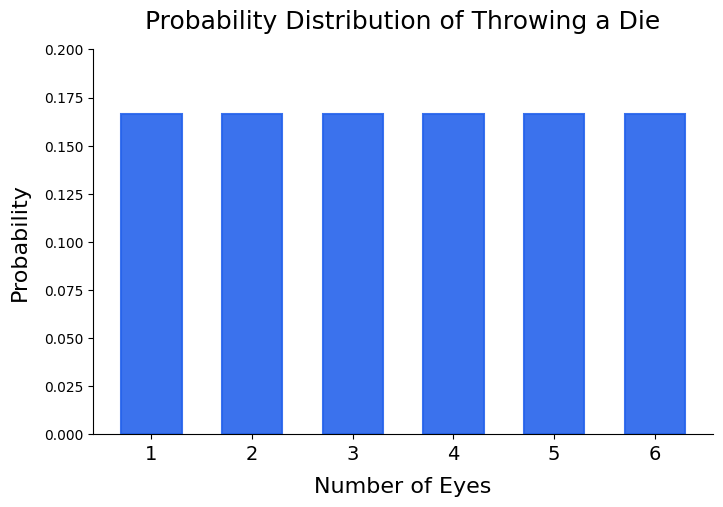

In [13]:
# Theoretical probability distribution for a fair dice (same design as simulation)
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.edgecolor': 'black',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white'
})

faces = np.arange(1, 7)
probs = np.full(6, 1/6)  # P(X=k) = 1/6 for each k in {1,...,6}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(faces, probs, color="#2563eb", alpha=0.9, edgecolor="#2563eb", linewidth=1.5, width=0.6)

ax.set_xticks(faces)
ax.set_xticklabels(faces, fontsize=14)
ax.set_xlabel("Number of Eyes", fontsize=16, labelpad=10)
ax.set_ylabel("Probability", fontsize=16, labelpad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, 1/6 * 1.2)
ax.set_title("Probability Distribution of Throwing a Die", fontsize=18, pad=15)

fig.savefig("dice_theoretical.png", dpi=300, transparent=True, bbox_inches="tight")
plt.show()

Saved 'uniform_box.png'.


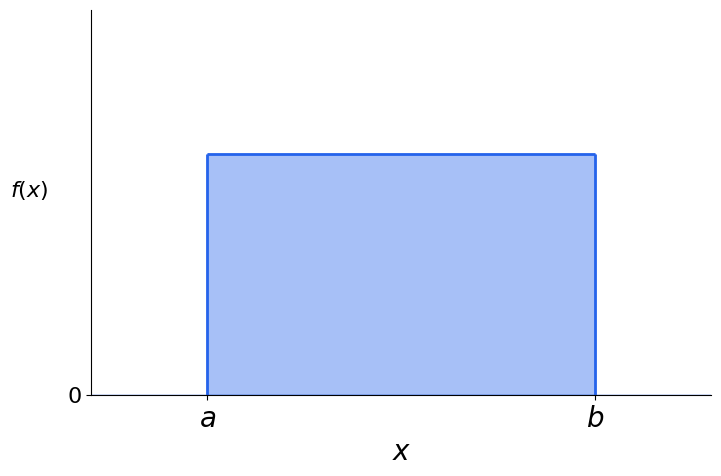

In [17]:
# ---------------------------
# UNIFORM DISTRIBUTION (BOX) PLOT — Black text, white background, blue box
# Self-contained: only numpy and matplotlib (no other cells required).
# ---------------------------
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.edgecolor': 'black',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white'
})

c, d = 1.5, 6.5
height = 0.5
box_blue = "#2563eb"
x_min, x_max = 0, 8

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Draw box: fill between c and d at height
ax.fill_between([c, d], 0, height, color=box_blue, alpha=0.4)
ax.hlines(height, c, d, colors=box_blue, linewidth=2.0)
ax.vlines([c, d], 0, height, colors=box_blue, linewidth=2.0)
ax.hlines(0, x_min, x_max, colors=box_blue, linewidth=1.0)

ax.set_xticks([c, d])
ax.set_xticklabels([r"$a$", r"$b$"], fontsize=20)
ax.set_yticks([0])
ax.set_yticklabels(["0"], fontsize=16)
ax.set_xlabel(r"$x$", fontsize=20)
ax.set_ylabel(r"$f(x)$", fontsize=16)
ax.yaxis.label.set_rotation(0)
ax.yaxis.set_label_coords(-0.1, 0.5)
ax.set_ylim(0, height + 0.3)
ax.set_xlim(x_min, x_max)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

fig.savefig("uniform_box.png", dpi=300, transparent=False, facecolor='white', bbox_inches="tight")
print("Saved 'uniform_box.png'.")
plt.show()

Saved 'die_cdf_light.png'.


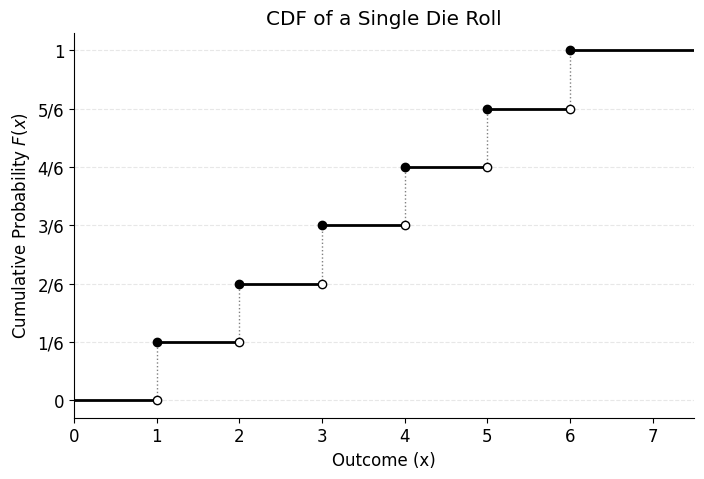

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# STYLE SETTINGS (Light Theme: White BG, Black Text)
# ---------------------------
plt.rcParams.update({
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.edgecolor': 'black',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'font.size': 12
})

if __name__ == "__main__":
    
    # 1. Data Setup
    # Outcomes: 1, 2, 3, 4, 5, 6
    x = np.arange(1, 7)
    # Cumulative Probability: 1/6, 2/6, ..., 6/6
    y = x / 6

    fig, ax = plt.subplots(figsize=(8, 5))

    # 2. Draw the Steps
    # a. The initial line from 0 to 1 (Prob = 0)
    ax.hlines(y=0, xmin=0, xmax=1, color='black', linewidth=2)
    
    # b. The steps for 1 through 6
    for i in range(len(x)):
        current_x = x[i]
        current_y = y[i]
        
        # Extend line to the next integer (or just off-chart for the last one)
        next_x = current_x + 1 if i < 5 else 7.5 
        
        # Draw horizontal line
        ax.hlines(y=current_y, xmin=current_x, xmax=next_x, color='black', linewidth=2)
        
        # Draw Solid Dot at (x, y) -> Includes this value (Right Continuous)
        ax.plot(current_x, current_y, 'o', color='black', markersize=6, zorder=3)
        
        # Draw Open Circle at (x, prev_y) -> Excludes previous value
        prev_y = 0 if i == 0 else y[i-1]
        ax.plot(current_x, prev_y, 'o', markerfacecolor='white', markeredgecolor='black', markersize=6, zorder=3)
        
        # Optional: Vertical dashed guide line to show the jump
        ax.vlines(x=current_x, ymin=prev_y, ymax=current_y, colors='gray', linestyles=':', linewidth=1)

    # 3. Formatting Axes
    
    # X-Axis: Integers 0 to 7
    ax.set_xticks(np.arange(0, 8))
    ax.set_xlim(0, 7.5)
    ax.set_xlabel("Outcome (x)")

    # Y-Axis: Fractions (1/6, 2/6...)
    yticks = np.concatenate(([0], y)) # [0, 1/6, ... 1]
    ylabels = ["0", "1/6", "2/6", "3/6", "4/6", "5/6", "1"]
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)
    ax.set_ylabel("Cumulative Probability $F(x)$")
    
    # Title
    ax.set_title("CDF of a Single Die Roll")

    # 4. Clean up styling
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, axis='y', linestyle='--', alpha=0.3) # Light horizontal grid

    # 5. Save
    fig.savefig("die_cdf_light.png", dpi=300, bbox_inches="tight")
    print("Saved 'die_cdf_light.png'.")
    
    plt.show()

Saved 'die_cdf_bars_light.png'.


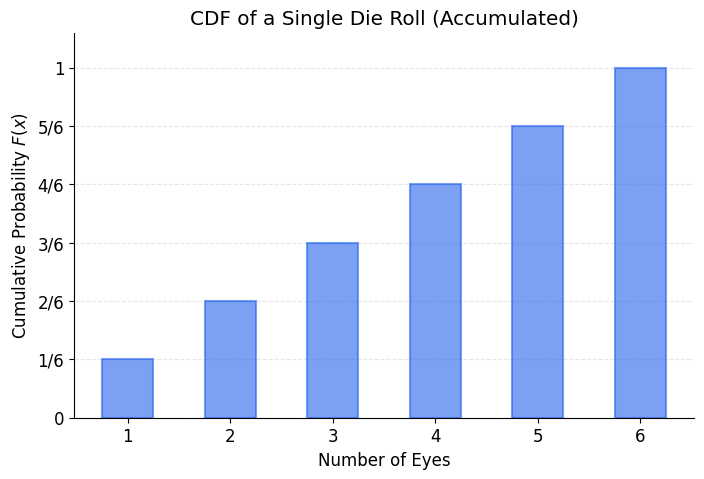

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# STYLE SETTINGS (Light Theme)
# ---------------------------
plt.rcParams.update({
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.edgecolor': 'black',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'font.size': 12
})

if __name__ == "__main__":
    
    # 1. Data Setup
    # Outcomes: 1, 2, 3, 4, 5, 6
    outcomes = np.arange(1, 7)
    
    # Cumulative Probabilities: 1/6, 2/6, 3/6, 4/6, 5/6, 6/6
    cdf_values = outcomes / 6

    # 2. Create Plot
    fig, ax = plt.subplots(figsize=(8, 5))

    # 3. Draw Vertical Bars
    # We use a slight alpha (transparency) so the bars aren't too heavy
    bars = ax.bar(
        outcomes, 
        cdf_values, 
        color='#2563eb', 
        alpha=0.6,          # 60% opacity
        edgecolor='#2563eb',  # Solid black border
        linewidth=1.5,
        width=0.5           # Thinner bars look cleaner
    )

    # 4. Axis Formatting
    
    # X-Axis: 1 to 6
    ax.set_xticks(outcomes)
    ax.set_xticklabels(outcomes)
    ax.set_xlabel("Number of Eyes")

    # Y-Axis: Fractions
    yticks = np.linspace(0, 1, 7) # [0, 1/6, 2/6 ... 1]
    ylabels = ["0", "1/6", "2/6", "3/6", "4/6", "5/6", "1"]
    
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)
    ax.set_ylim(0, 1.1) # Little bit of headroom
    ax.set_ylabel("Cumulative Probability $F(x)$")

    # 5. Clean Up
    ax.set_title("CDF of a Single Die Roll (Accumulated)")
    
    # Remove top and right frame lines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add a light grid behind the bars for easier reading
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
    ax.set_axisbelow(True) # Puts grid behind bars

    # 6. Save and Show
    fig.savefig("die_cdf_bars_light.png", dpi=300, bbox_inches="tight")
    print("Saved 'die_cdf_bars_light.png'.")
    
    plt.show()

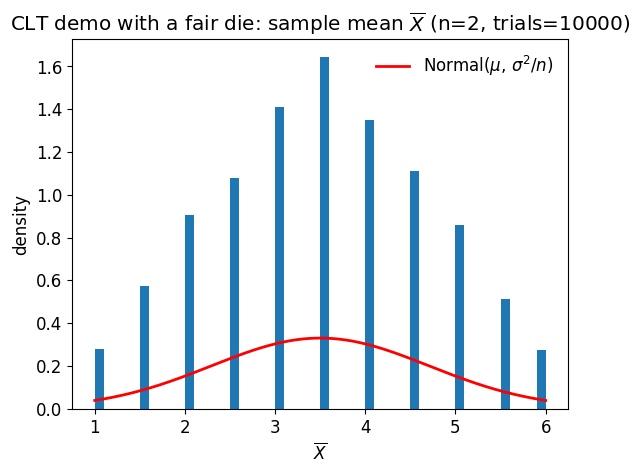

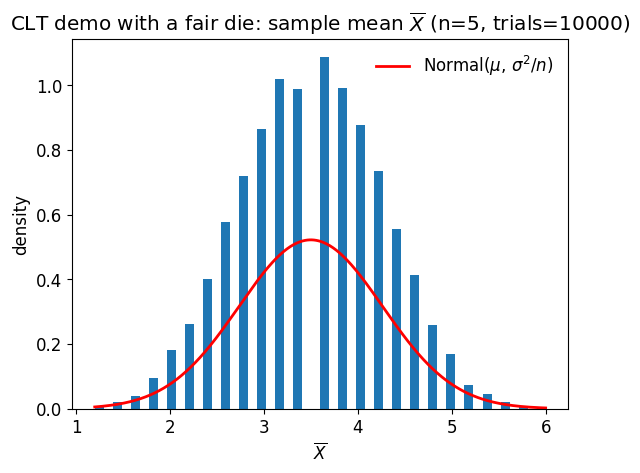

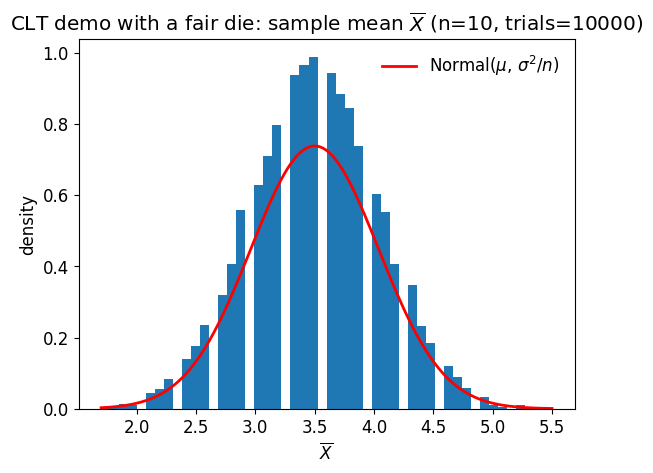

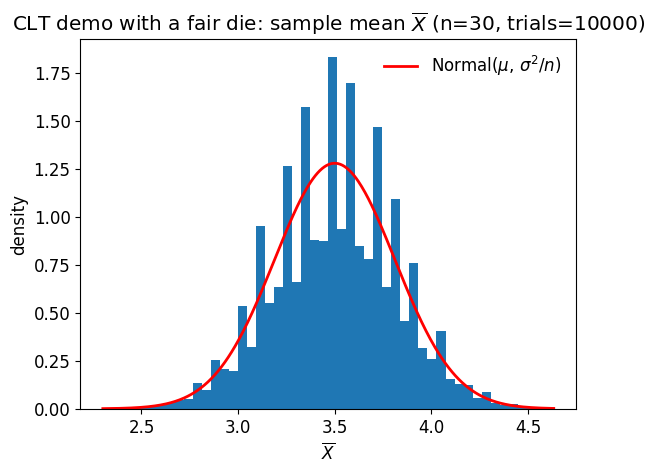

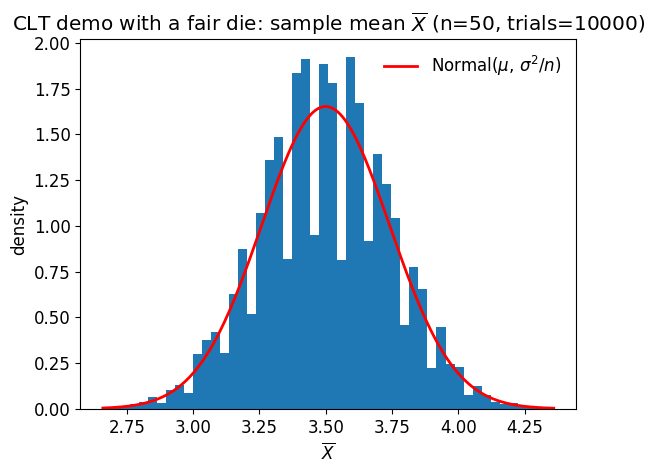

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def clt_die_demo(n=30, trials=10_000, bins=50, seed=42):
    rng = np.random.default_rng(seed)

    # Roll a die: integers 1..6
    rolls = rng.integers(1, 7, size=(trials, n))
    xbar = rolls.mean(axis=1)

    # True mean and sd for one fair die
    mu = 3.5
    sigma = np.sqrt(35 / 12)

    # NOTE: Now we simply use the actual means, not the standardised version!
    # Plot histogram of sample means xbar
    plt.figure()
    plt.hist(xbar, bins=bins, density=True)
    plt.title(f"CLT demo with a fair die: sample mean $\\overline{{X}}$ (n={n}, trials={trials})")
    plt.xlabel(r"$\overline{X}$")
    plt.ylabel("density")

    # Overlay actual normal pdf: N(mu, sigma^2/n)
    grid = np.linspace(np.min(xbar), np.max(xbar), 400)
    real_pdf = (1 / np.sqrt(2 * np.pi * (sigma**2 / n))) * np.exp(-(grid - mu)**2 / (2 * sigma**2 / n))
    plt.plot(grid, real_pdf, linewidth=2, color="red", label="Normal($\\mu$, $\\sigma^2/n$)")
    plt.legend()

    plt.show()

# Try a few n values:
for n in [2, 5, 10, 30, 50]:
    clt_die_demo(n=n, trials=10000, bins=50, seed=42)